# EDA

In [1]:
"""
Purpose of this script:
To explore the salient features of the given dataset (diabetes-130),
What are the categorical, numerical variables?
How many rows, many columns?
Any outliers? Where they exist?
How much % missing?
Distribution, which columns is skewed?
Find some patterns between the data and what we are potentially interested in.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow
import statsmodels.api as sm
import scipy

import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
data_path = "../data/"
output_path = "../output/"

### Fetch data from pre-saved parquet file

In [3]:
data = pd.read_parquet(data_path + "diabetes_130_full.parquet")
data.drop(columns = ['encounter_id', 'patient_nbr'], inplace = True)

In [4]:
### Assign relevant item mapping to id from csv

IDs_mapping = pd.read_csv(data_path + "IDS_mapping.csv")

admission_id_mapping = IDs_mapping.iloc[:8, :]
admission_id_mapping['admission_type_id'] = admission_id_mapping['admission_type_id'].astype(int)
admission_id_mapping = admission_id_mapping.set_index('admission_type_id')['description'].to_dict()

discharge_id_mapping = IDs_mapping.iloc[10:40, :]
discharge_id_mapping['admission_type_id'] = discharge_id_mapping['admission_type_id'].astype(int)
discharge_id_mapping = discharge_id_mapping.set_index('admission_type_id')['description'].to_dict()

admission_source_id_mapping = IDs_mapping.iloc[42:, :]
admission_source_id_mapping['admission_type_id'] = admission_source_id_mapping['admission_type_id'].astype(int)
admission_source_id_mapping = admission_source_id_mapping.set_index('admission_type_id')['description'].to_dict()

data['admission_type_id'] = data['admission_type_id'].map(admission_id_mapping)
data['discharge_disposition_id'] = data['discharge_disposition_id'].map(discharge_id_mapping)
data['admission_source_id'] = data['admission_source_id'].map(admission_source_id_mapping)

In [5]:
X = pd.read_parquet(data_path + "diabetes_130_X.parquet")
y = pd.read_parquet(data_path + "diabetes_130_y.parquet")

### Fetch data directly from API (First Call)

In [6]:
from ucimlrepo import fetch_ucirepo, list_available_datasets
# import pprint

diabetes_dataset = fetch_ucirepo(id=296)
# diabetes_dataset.variables

In [7]:
# getting info directly from the pre-describe metadata first
diabetes_dataset_info = pd.read_csv(data_path + "dataset_description.csv")

In [8]:
diabetes_dataset.metadata.missing_values_symbol 
# This means only value of NaN represent the true missing value. 

'NaN'

### Summary Statistics (Basic Overview)

In [9]:
"""
Purpose is to explore the following:
Dataset shape - rows, columns
Data types - numeric, categorical
Missing values - count, percentage
Duplicate rows - exact and near-duplicates
Unique values per column
Cardinality of categorical variables
"""
pass

In [10]:
data.shape 
# 101,766 rows, 48 cols

(101766, 48)

In [11]:
pd.set_option("display.max_rows", 60)

In [12]:
# Descriptive statistics
data.describe()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [13]:
# Features vs Target

features = X.columns.tolist()
target = y.columns.tolist()

print(f"X = {features}\n")
print(f"y = {target}\n")

print(f"num_X = {len(features)}") # 47 features
print(f"num_y = {len(target)}")   # 1 target

X = ['race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']

y = ['readmitted']

num_X = 47
num_y = 1


In [14]:
# Type of variables
pre_described_data = diabetes_dataset_info.copy()

categorical_var = pre_described_data[pre_described_data['type'] == 'Categorical']['name'].tolist()
numerical_var = pre_described_data[pre_described_data['type'] == 'Integer']['name'].tolist()
medication_var = [col for col in pre_described_data['name'] if any(med in col.lower() for med in 
                  ['metformin', 'glipizide', 'glyburide', 'insulin', 'pioglitazone', 
                   'rosiglitazone', 'repaglinide', 'nateglinide', 'chlorpropamide',
                   'glimepiride', 'acetohexamide', 'tolbutamide', 'acarbose', 'miglitol',
                   'troglitazone', 'tolazamide', 'examide', 'citoglipton'])]

print(f"num_of_categorical_var: {len(categorical_var)}")
print(f"num_of_numerical_var: {len(numerical_var)}")
print(f"num_of_medication_var: {len(medication_var)}")

num_of_categorical_var: 40
num_of_numerical_var: 8
num_of_medication_var: 23


In [15]:
# Missing Analysis (% Missing)

var_with_missing = pre_described_data[pre_described_data['missing_values'] == 'yes']['name'].tolist()
missing_results = data[var_with_missing].isnull().sum() / len(data)

print("\nVariables with any missing values (descending)")
missing_results.sort_values(ascending = False)


Variables with any missing values (descending)


weight               0.968585
medical_specialty    0.490822
payer_code           0.395574
race                 0.022336
diag_3               0.013983
diag_2               0.003518
diag_1               0.000206
dtype: float64

In [16]:
# decide to drop weight first, very high missing rate (97%). Drop payer_code also, dont think there's relevance at all.
# keep medical_speciality first, might be valuable knowing who admitted them.

data_clean = data.drop(columns = ['weight', 'payer_code'], axis = 1)

In [17]:
data.race.value_counts() / len(data)

race
Caucasian          0.747784
AfricanAmerican    0.188766
Hispanic           0.020017
Other              0.014799
Asian              0.006299
Name: count, dtype: float64

In [18]:
df = data_clean.copy()

### Target Variable Analysis (Re-admission Status)



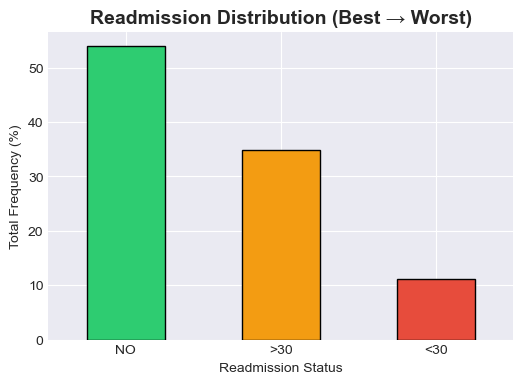

In [19]:
"""
I think we can interpret the readmitted status as Ordinal, rather than Nominal.
NO → >30 → <30 (with increasing level of medical concern)
"""

ordinal_mapping = {'NO': 0, '>30': 1, '<30': 2}
df['readmitted_ordinal'] = df['readmitted'].map(ordinal_mapping)

readmit_order = ['NO', '>30', '<30']
colors = ['#2ecc71', '#f39c12', '#e74c3c']  # Green → Orange → Red

target_pct = df['readmitted'].value_counts(normalize = True).reindex(readmit_order) * 100

plt.figure(figsize=(6,4))
target_pct.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Readmission Distribution (Best → Worst)', fontsize=14, fontweight='bold')
plt.xlabel('Readmission Status')
plt.ylabel('Total Frequency (%)')
plt.xticks(rotation=0)
plt.show()

### Numerical Variable Analysis

#### Histogram Distribution

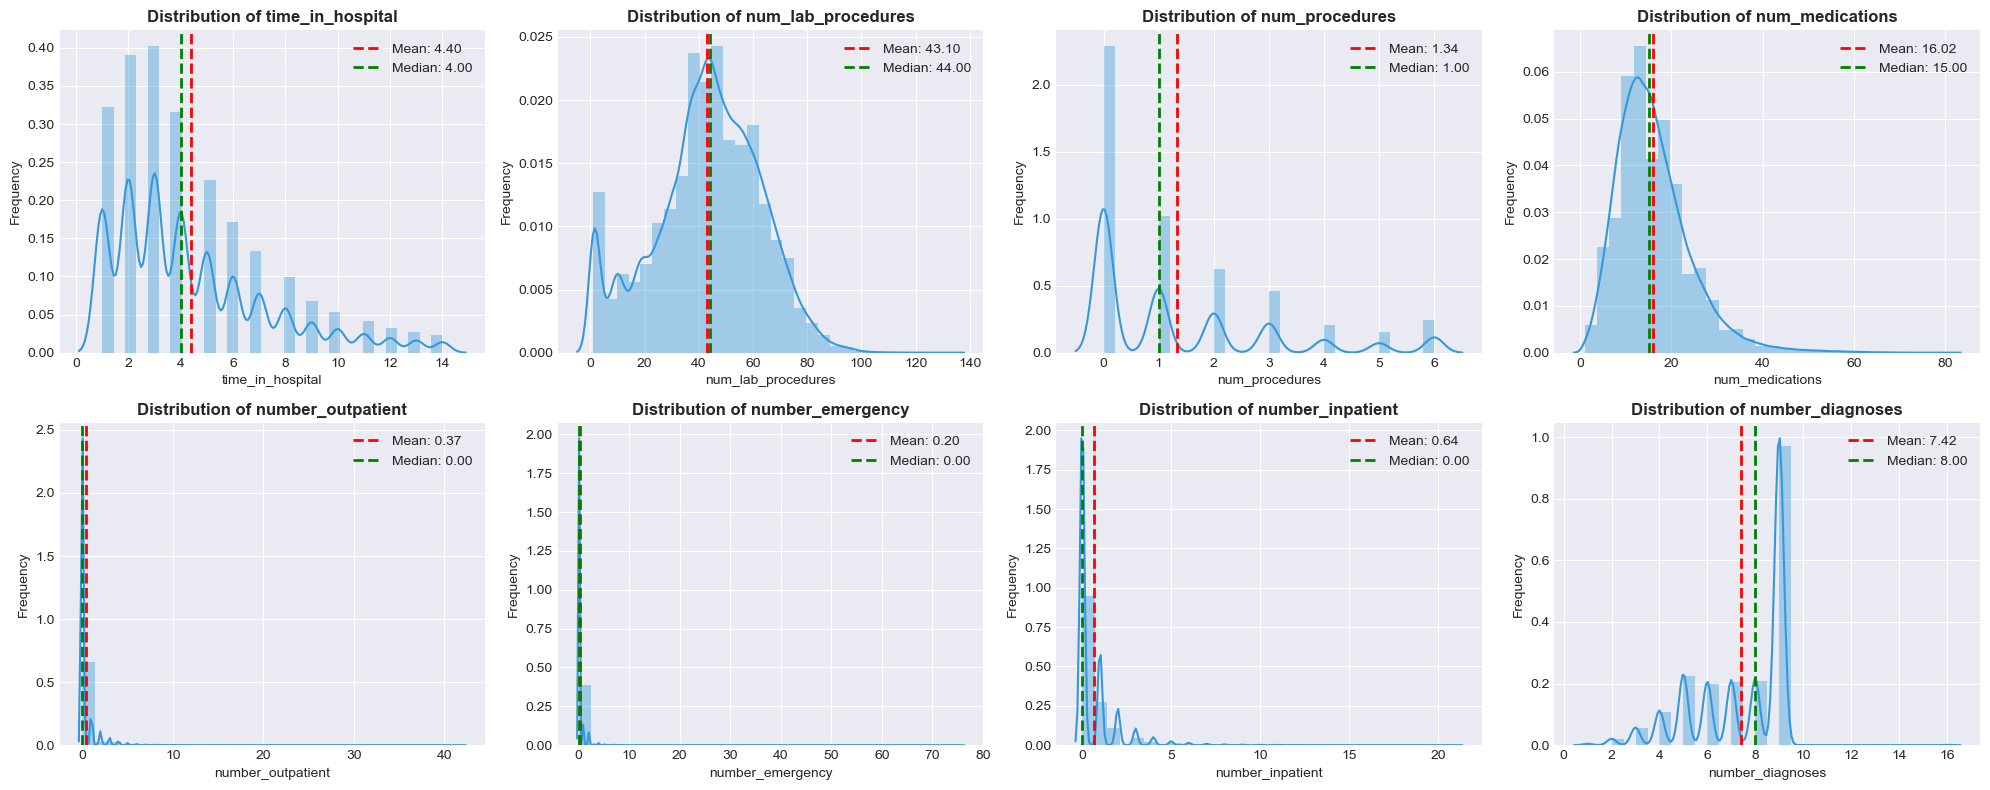

In [20]:
# Layout setup - 4 graphs side by side per row.
n_cols = 4
n_rows = (len(numerical_var) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_var):
    sns.distplot(df[col], bins=30, kde=True, color="#3498db", ax=axes[i])

    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[i].axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_val:.2f}")
    axes[i].axvline(median_val, color="green", linestyle="--", linewidth=2, label=f"Median: {median_val:.2f}")

    axes[i].set_title(f"Distribution of {col}", fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].legend()

plt.tight_layout()
plt.show()

#### Skewness Analysis (Kurtosis)

               Column   Skewness     Kurtosis         Skew_Type
0    number_emergency  22.855582  1191.686726      Right Skewed
1   number_outpatient   8.832959   147.907736      Right Skewed
2    number_inpatient   3.614139    20.719397      Right Skewed
3     num_medications   1.326672     3.468155      Right Skewed
4      num_procedures   1.316415     0.857110      Right Skewed
5    time_in_hospital   1.133999     0.850251      Right Skewed
6  num_lab_procedures  -0.236544    -0.245074  Fairly Symmetric
7    number_diagnoses  -0.876746    -0.079056       Left Skewed 



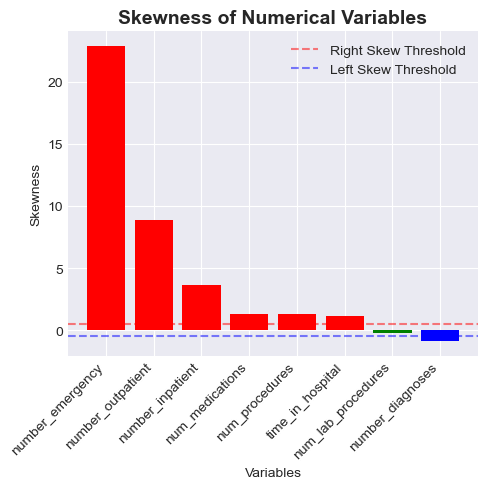

In [21]:
skewness_data = []
for col in numerical_var:
    col_skew = df[col].skew()
    col_kurt = df[col].kurtosis()
    skewness_data.append({
        'Column': col,
        'Skewness': col_skew,
        'Kurtosis': col_kurt,
        'Skew_Type': 'Right Skewed' if col_skew > 0.5 else 'Left Skewed' if col_skew < -0.5 else 'Fairly Symmetric'
    })

skewness_df = pd.DataFrame(skewness_data).sort_values('Skewness', ascending=False).reset_index(drop = True)

print(skewness_df, "\n")

# Visualize skewness
plt.figure(figsize=(5, 5))
colors = ['red' if x > 0.5 else 'blue' if x < -0.5 else 'green' for x in skewness_df['Skewness']]
plt.bar(range(len(skewness_df)), skewness_df['Skewness'], color=colors)
plt.xticks(range(len(skewness_df)), skewness_df['Column'], rotation=45, ha='right')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Right Skew Threshold')
plt.axhline(y=-0.5, color='b', linestyle='--', alpha=0.5, label='Left Skew Threshold')
plt.xlabel('Variables')
plt.ylabel('Skewness')
plt.title('Skewness of Numerical Variables', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

#### Outlier analysis


📊 Outlier Summary (IQR Method):
               Column  Outlier_Count  Outlier_Percentage  Lower_Bound  \
4   number_outpatient          16739           16.448519          0.0   
5    number_emergency          11383           11.185465          0.0   
6    number_inpatient           7049            6.926675         -1.5   
2      num_procedures           4954            4.868031         -3.0   
3     num_medications           2557            2.512627         -5.0   
0    time_in_hospital           2252            2.212920         -4.0   
7    number_diagnoses            281            0.276124          1.5   
1  num_lab_procedures            143            0.140518         -8.0   

   Upper_Bound  Min  Max  
4          0.0    0   42  
5          0.0    0   76  
6          2.5    0   21  
2          5.0    0    6  
3         35.0    1   81  
0         12.0    1   14  
7         13.5    1   16  
1         96.0    1  132  


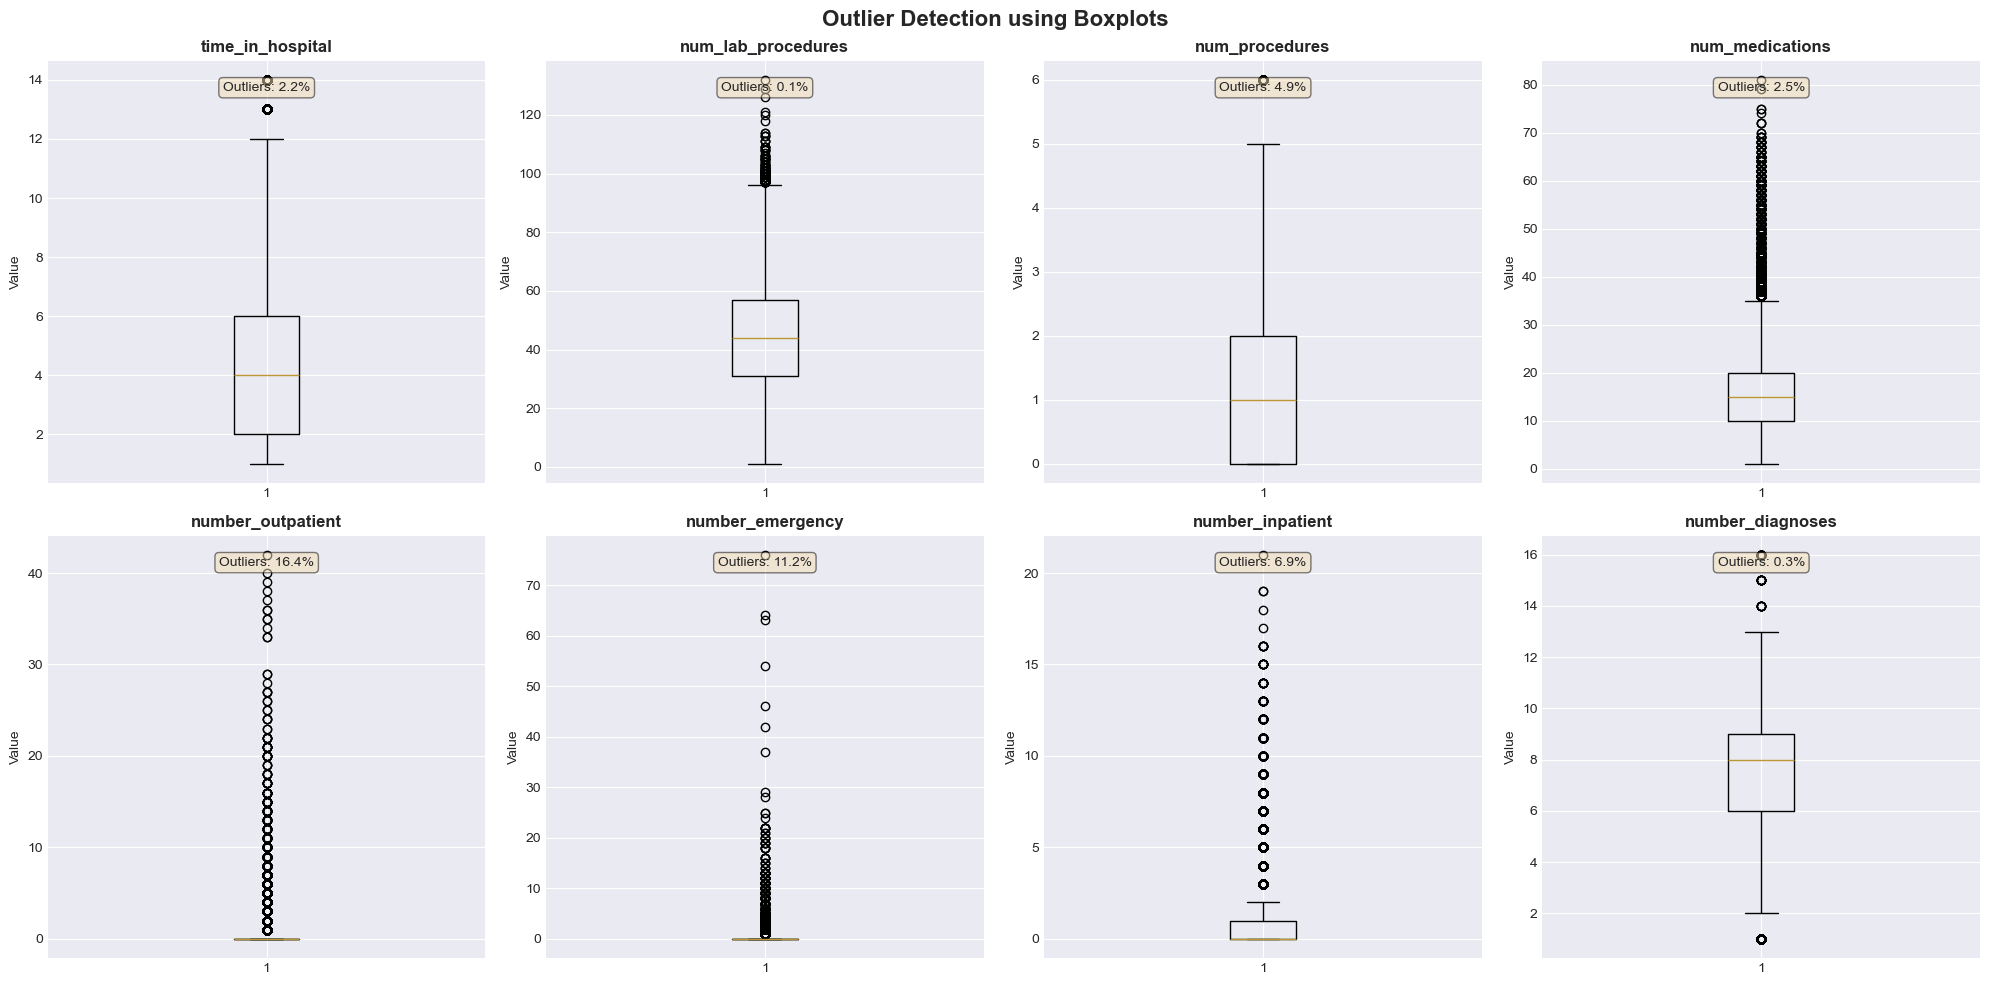

In [22]:
outlier_summary = []
for col in numerical_var:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df)) * 100
    
    outlier_summary.append({
        'Column': col,
        'Outlier_Count': outlier_count,
        'Outlier_Percentage': outlier_percentage,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Min': df[col].min(),
        'Max': df[col].max()
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier_Percentage', ascending=False)
print("\n📊 Outlier Summary (IQR Method):")
print(outlier_df)

fig, axes = plt.subplots(2, (len(numerical_var) + 1) // 2, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_var):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_ylabel('Value')
    
    # Add outlier percentage
    outlier_pct = outlier_df[outlier_df['Column'] == col]['Outlier_Percentage'].values[0]
    axes[i].text(0.5, 0.95, f'Outliers: {outlier_pct:.1f}%', 
                transform=axes[i].transAxes, ha='center', va='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Outlier Detection using Boxplots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Relationship between numerical vs target-ordinal variable

#### Correlation amongst numerical features

In [23]:
numerical_with_target = numerical_var.copy()
numerical_with_target.append('readmitted_ordinal')

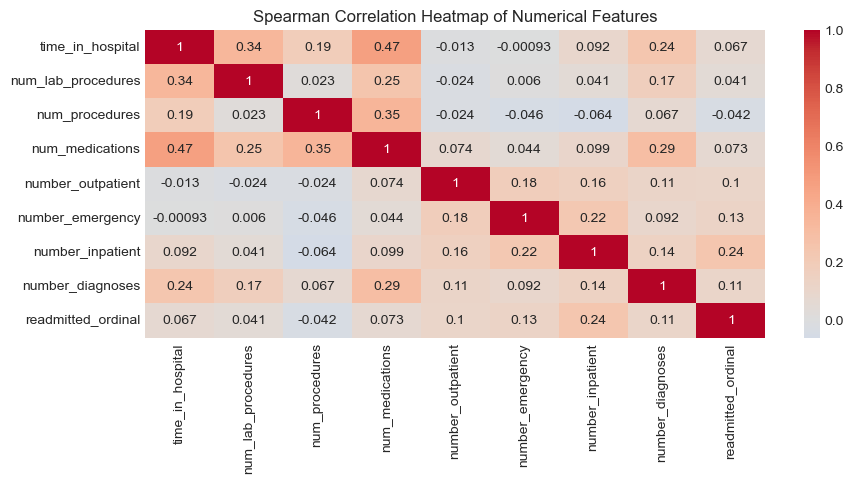

In [24]:
corr_matrix = df[numerical_with_target].corr(method='spearman')

plt.figure(figsize=(10,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Spearman Correlation Heatmap of Numerical Features")
plt.show()

#### Somers'D - measure the concordance between 2 ordering variables

In [25]:
results = []
for col in numerical_var:
    somers_d = scipy.stats.somersd(df[col], df['readmitted_ordinal'])
    results.append({
        "Variable": col,
        "SomersD": somers_d.statistic,
        "p_value": somers_d.pvalue
    })

somers_df = pd.DataFrame(results).sort_values("SomersD", ascending=False)
print(somers_df)

# seems like the top 3 variable here have some linear relationship with the ordinal variables

             Variable   SomersD        p_value
6    number_inpatient  0.229152   0.000000e+00
5    number_emergency  0.200836   0.000000e+00
4   number_outpatient  0.136981  1.233267e-238
7    number_diagnoses  0.083316  1.164964e-261
3     num_medications  0.045637  1.126444e-122
0    time_in_hospital  0.044786  1.325255e-101
1  num_lab_procedures  0.024752   3.440149e-39
2      num_procedures -0.032415   2.025160e-40


#### Box-plots to compare numerical variables vs multiclass target variable

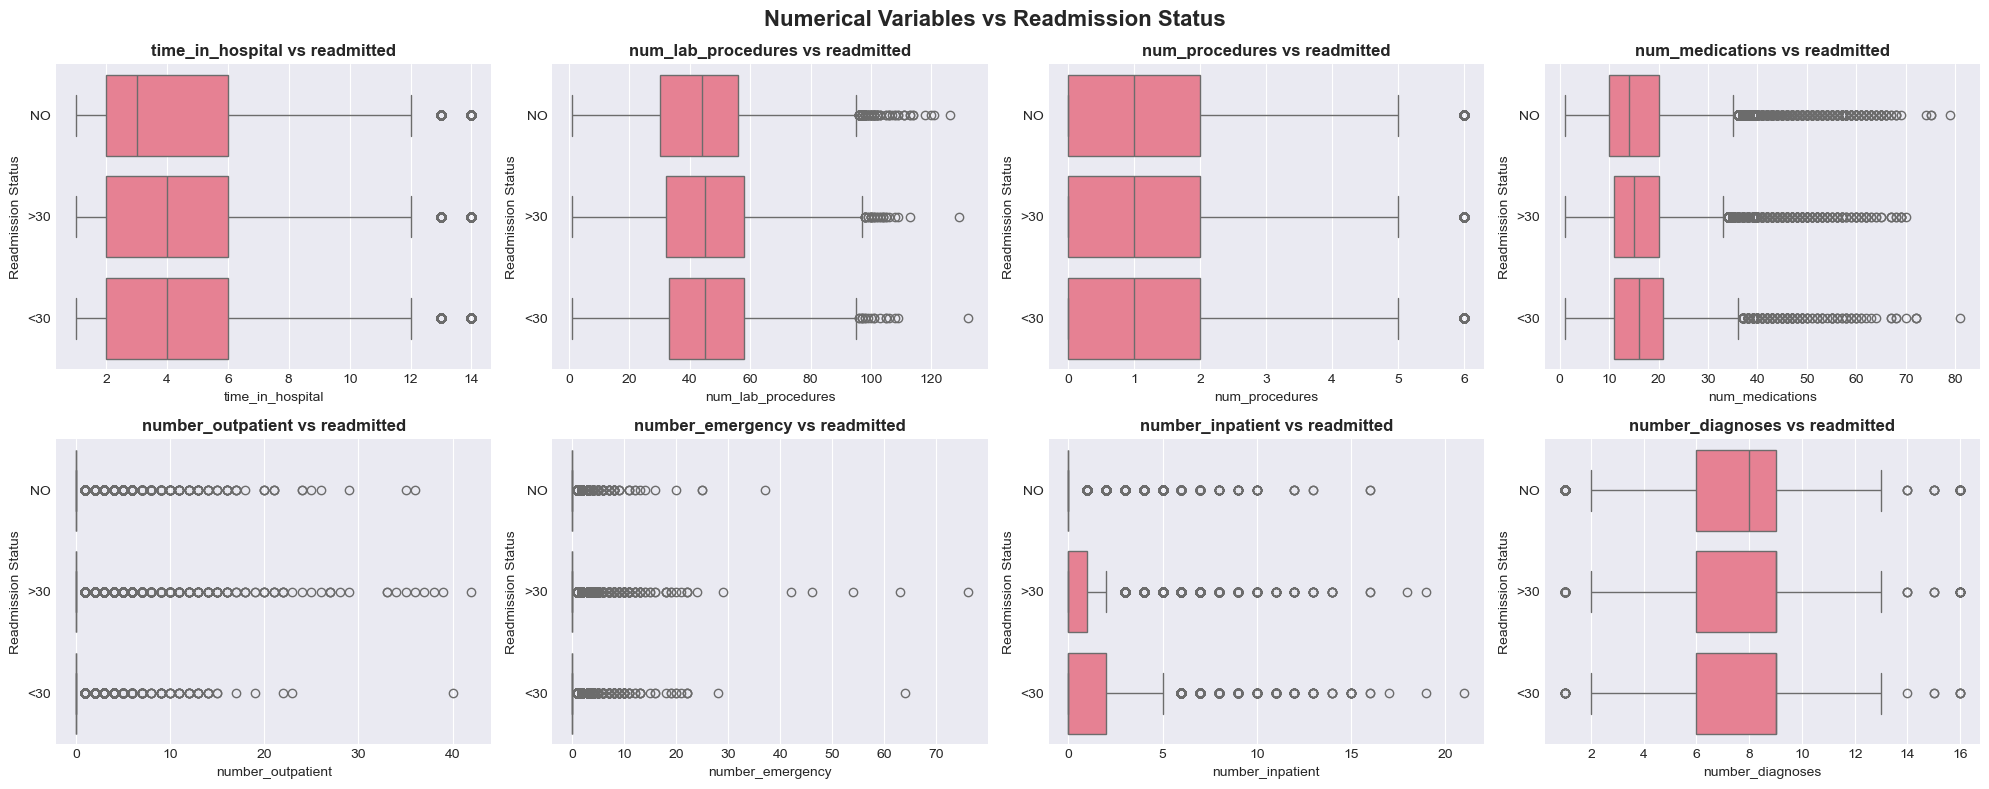

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

n_cols = 4
n_rows = (len(numerical_var) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

target = 'readmitted' 

for i, col in enumerate(numerical_var):
    sns.boxplot(x=col, y=target, data=df, ax=axes[i], order=["NO", ">30", "<30"])
    axes[i].set_title(f'{col} vs {target}', fontweight='bold')
    axes[i].set_ylabel('Readmission Status')

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Numerical Variables vs Readmission Status', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# can tell that time_in_hospital quite relevant to different between readmitted vs no readmitted, the median quite different. 
# quite significant relationship for number_inpatient against target variable also

### Categorical Variable Analysis

#### Bar plot distribution

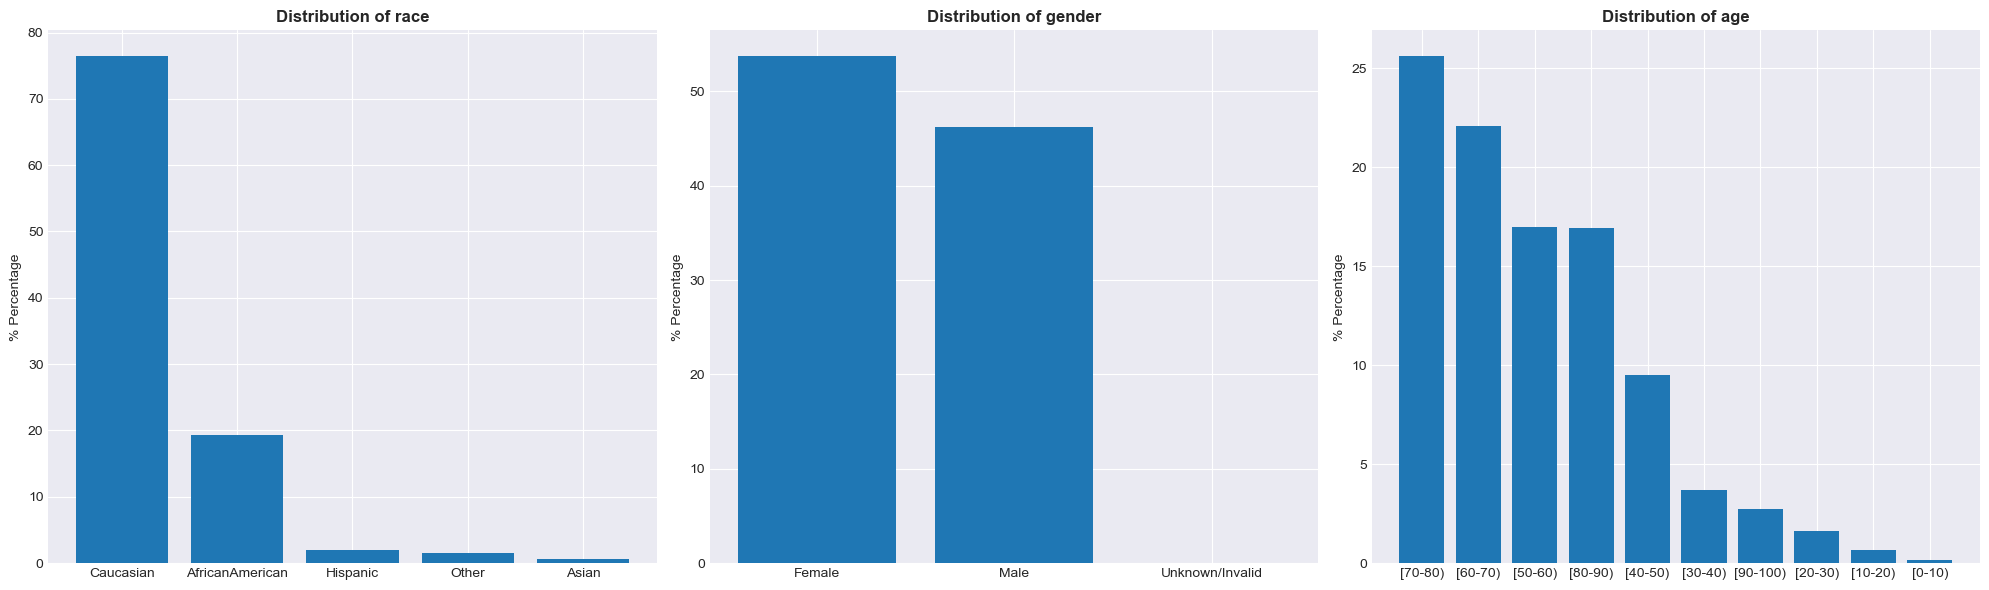

In [27]:
key_categorical = ['race', 'gender', 'age']

n_cols = 3
n_rows = (len(key_categorical) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 6))
axes = axes.flatten()

for i, col in enumerate(key_categorical):
    if col in df.columns:

        value_counts = df[col].value_counts(normalize=True) * 100
        axes[i].bar(range(len(value_counts)), value_counts.values, color = '#1f77b4')
        axes[i].set_xticks(range(len(value_counts)))
        axes[i].set_xticklabels(value_counts.index, rotation=0, ha='center')
        axes[i].set_title(f'Distribution of {col}', fontweight='bold')
        axes[i].set_ylabel('% Percentage')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

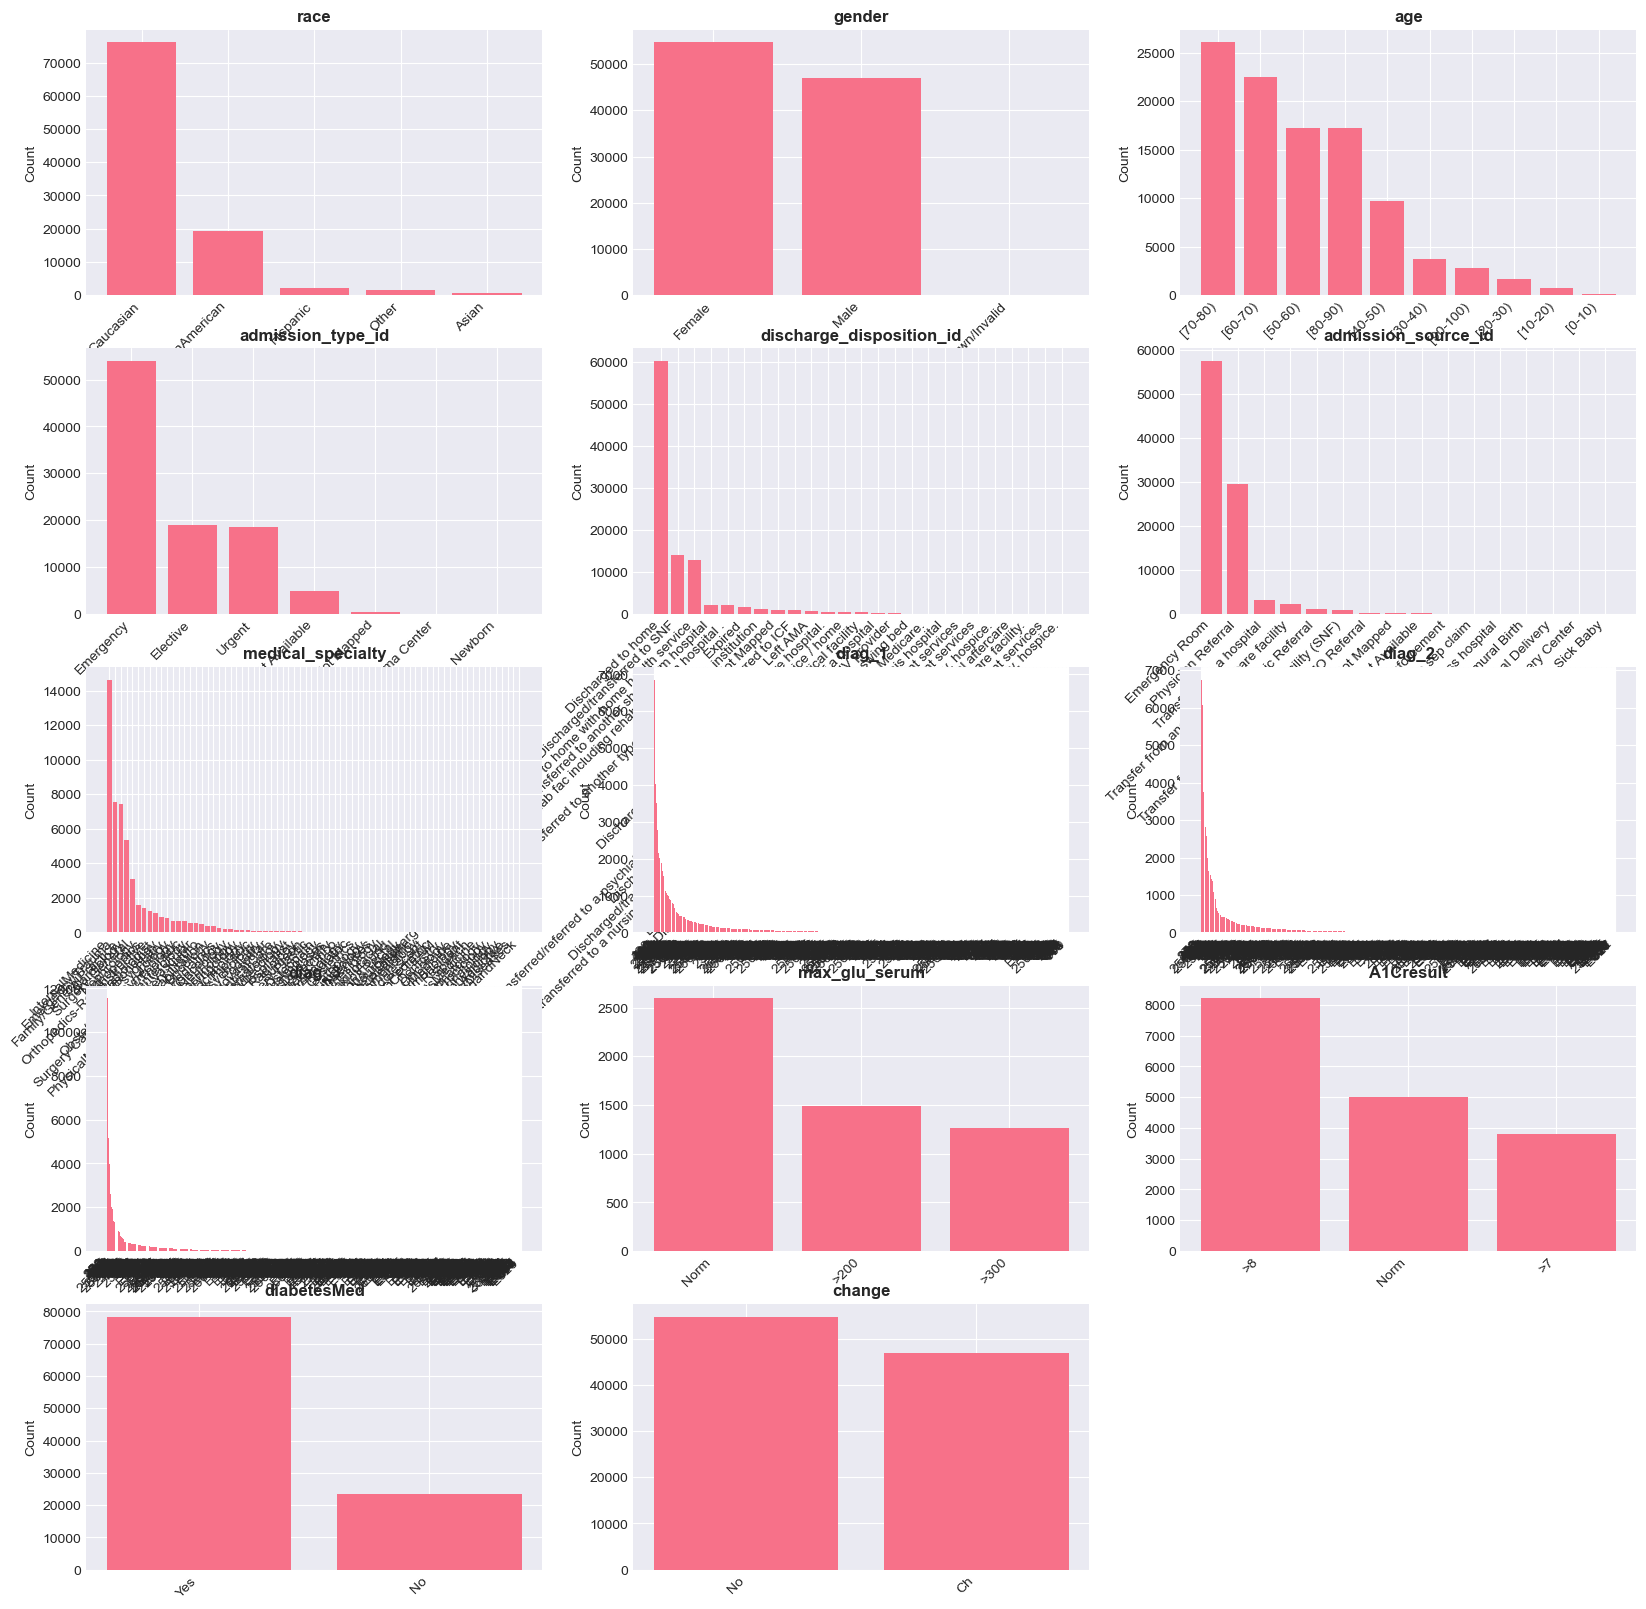

In [28]:
# Analyze key categorical variables
key_categorical = ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 
                  'admission_source_id', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 
                   'max_glu_serum', 'A1Cresult', 'diabetesMed', 'change']

n_cols = 3
n_rows = (len(key_categorical) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(key_categorical[:]):
    if col in df.columns:
        value_counts = df[col].value_counts()
        axes[i].bar(range(len(value_counts)), value_counts.values)
        axes[i].set_xticks(range(len(value_counts)))
        axes[i].set_xticklabels(value_counts.index, rotation=45, ha='right')
        axes[i].set_title(f'{col}', fontweight='bold')
        axes[i].set_ylabel('Count')

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

#### PATTERNS WITH TARGET VARIABLE (READMISSION)

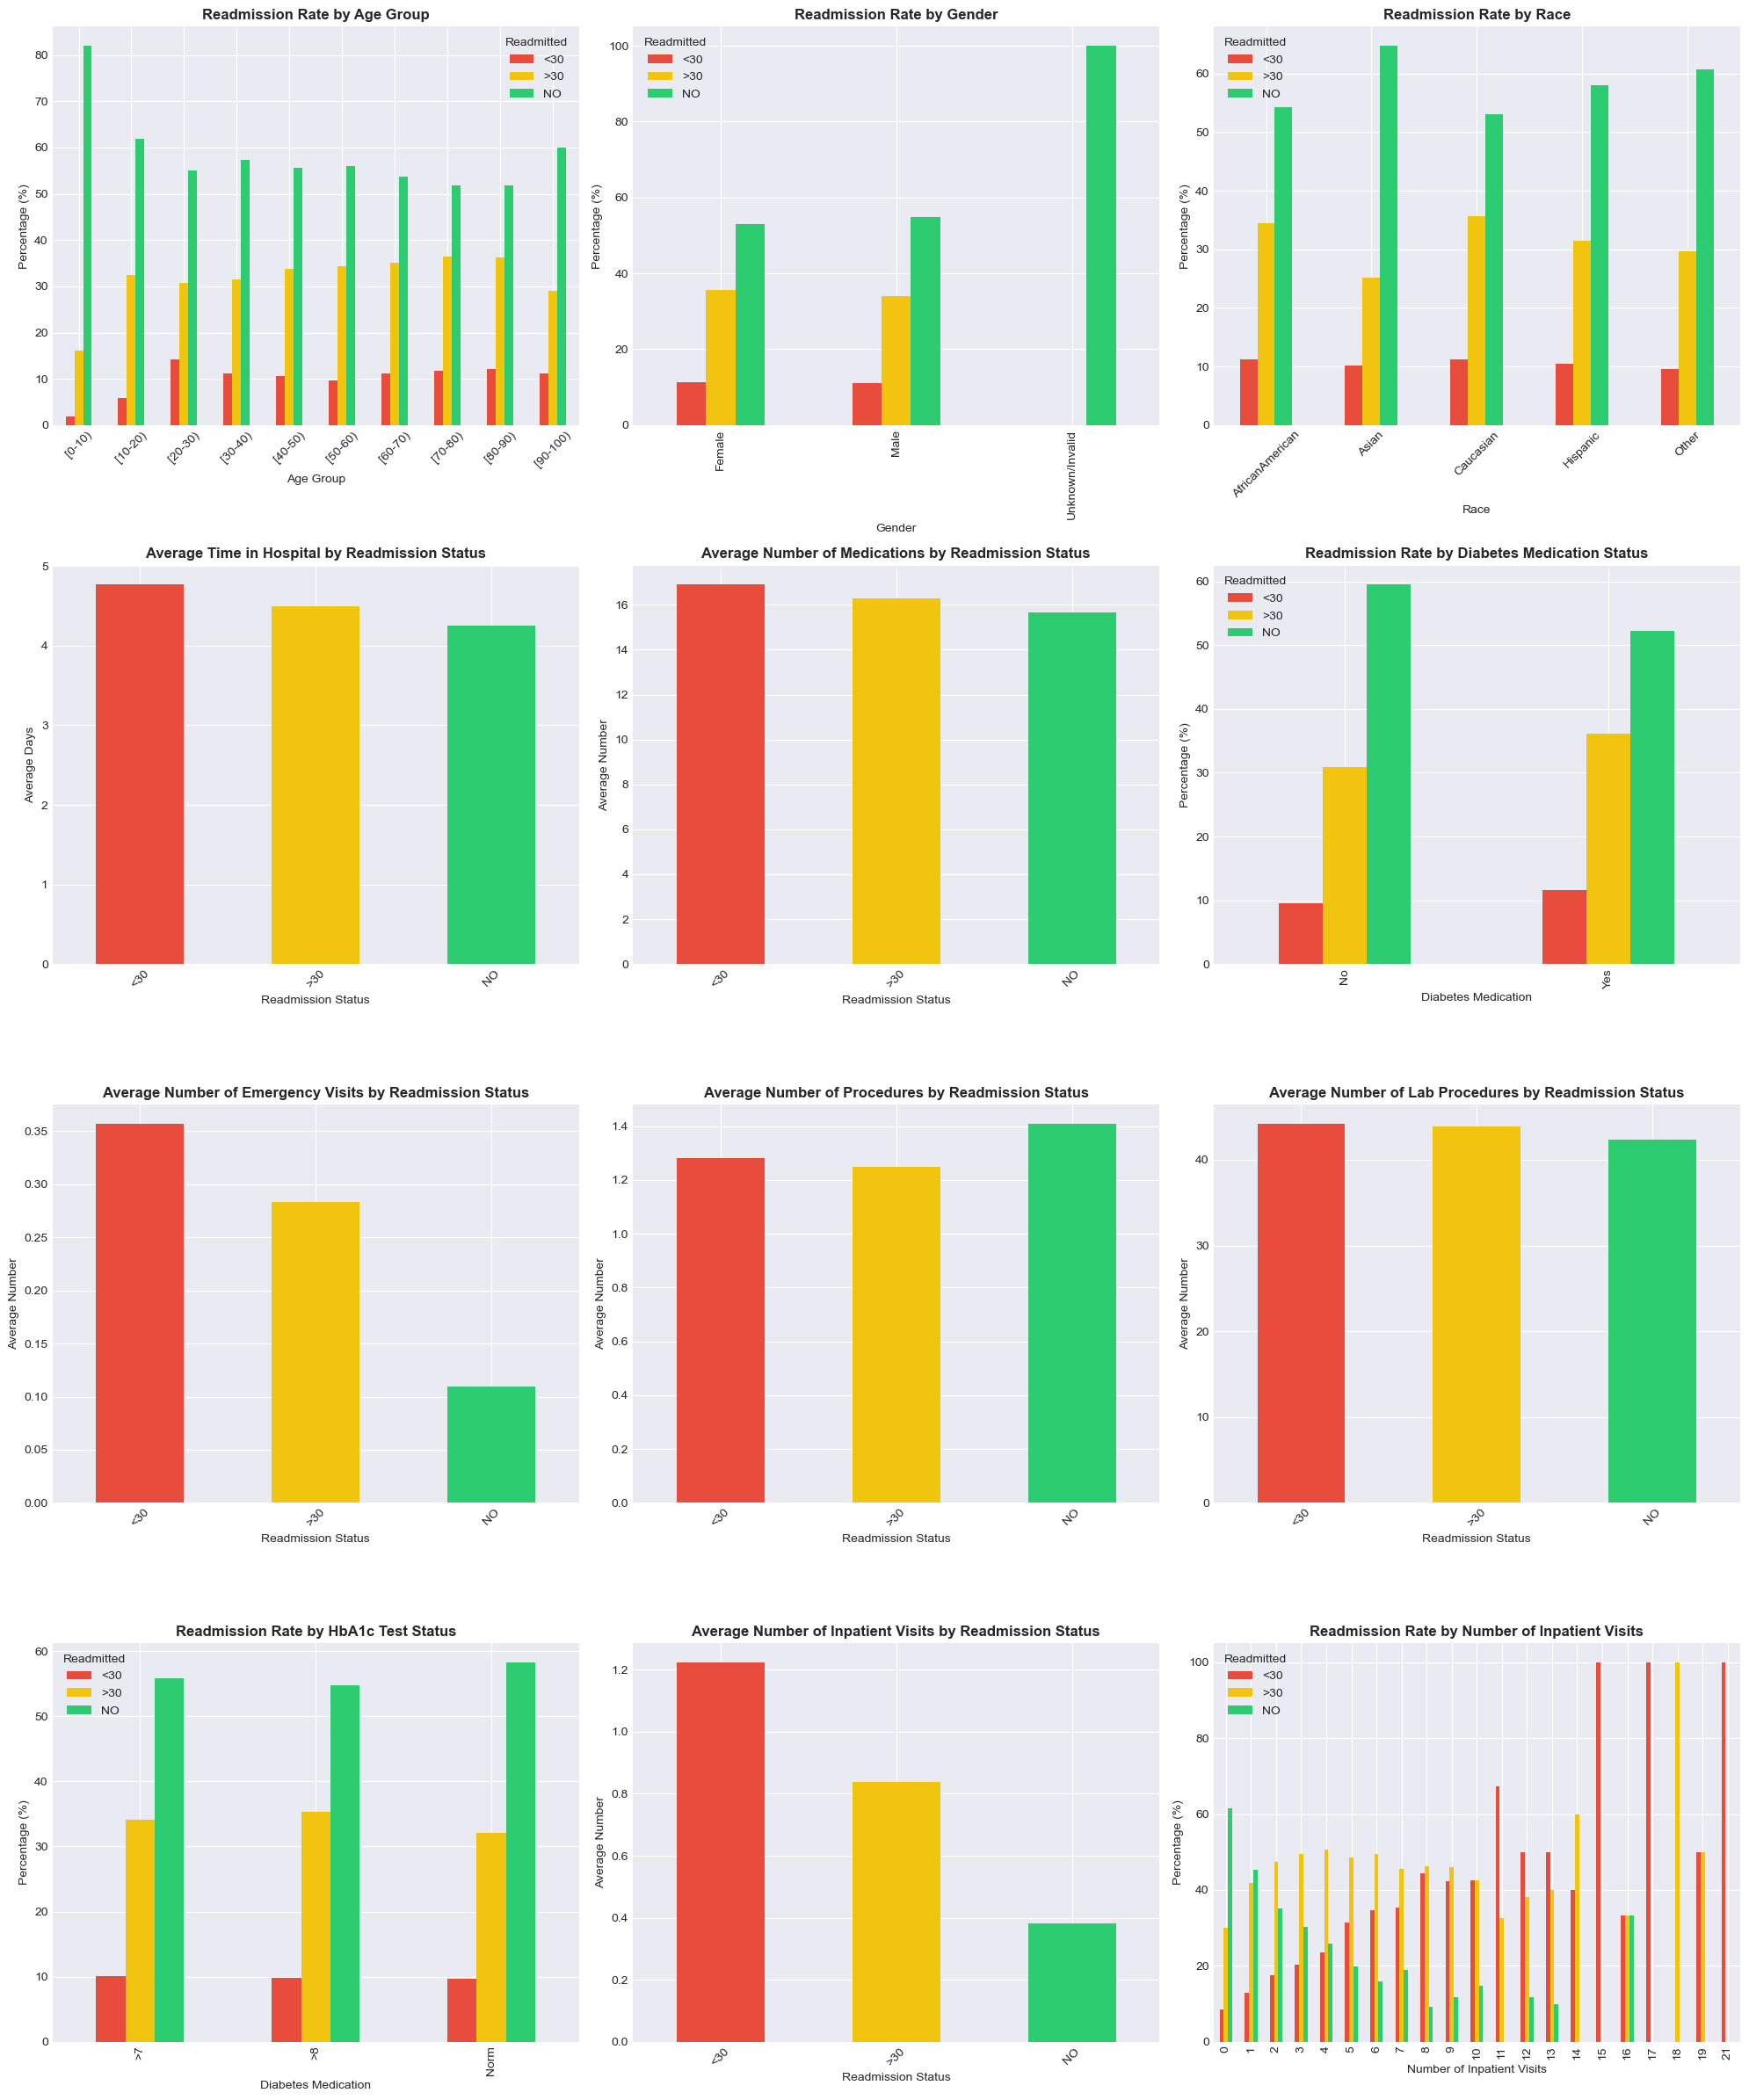

In [29]:
# Readmission rate by demographic factors
fig, axes = plt.subplots(4, 3, figsize=(20, 24))

colors = ['#E74C3C','#F1C40F','#2ECC71']

# Age vs Readmission
readmit_age = pd.crosstab(df['age'], df['readmitted'], normalize='index') * 100
readmit_age.plot(kind='bar', stacked=False, ax=axes[0, 0], color = colors)
axes[0, 0].set_title('Readmission Rate by Age Group', fontweight='bold')
axes[0, 0].set_xlabel('Age Group')
axes[0, 0].set_ylabel('Percentage (%)')
axes[0, 0].legend(title='Readmitted')
axes[0, 0].tick_params(axis='x', rotation=45)

# Gender vs Readmission
readmit_gender = pd.crosstab(df['gender'], df['readmitted'], normalize='index') * 100
readmit_gender.plot(kind='bar', stacked=False, ax=axes[0, 1], color = colors)
axes[0, 1].set_title('Readmission Rate by Gender', fontweight='bold')
axes[0, 1].set_xlabel('Gender')
axes[0, 1].set_ylabel('Percentage (%)')
axes[0, 1].legend(title='Readmitted')

# Race vs Readmission
readmit_race = pd.crosstab(df['race'], df['readmitted'], normalize='index') * 100
readmit_race.plot(kind='bar', stacked=False, ax=axes[0, 2], color = colors)
axes[0, 2].set_title('Readmission Rate by Race', fontweight='bold')
axes[0, 2].set_xlabel('Race')
axes[0, 2].set_ylabel('Percentage (%)')
axes[0, 2].legend(title='Readmitted')
axes[0, 2].tick_params(axis='x', rotation=45)

# Time in hospital vs Readmission
readmit_time = df.groupby('readmitted')['time_in_hospital'].mean()
readmit_time.plot(kind='bar', ax=axes[1, 0], color = colors)
axes[1, 0].set_title('Average Time in Hospital by Readmission Status', fontweight='bold')
axes[1, 0].set_xlabel('Readmission Status')
axes[1, 0].set_ylabel('Average Days')
axes[1, 0].tick_params(axis='x', rotation=45)

# Number of medications vs Readmission
readmit_meds = df.groupby('readmitted')['num_medications'].mean()
readmit_meds.plot(kind='bar', ax=axes[1, 1], color = colors)
axes[1, 1].set_title('Average Number of Medications by Readmission Status', fontweight='bold')
axes[1, 1].set_xlabel('Readmission Status')
axes[1, 1].set_ylabel('Average Number')
axes[1, 1].tick_params(axis='x', rotation=45)

# Diabetes medication vs Readmission
readmit_diabmed = pd.crosstab(df['diabetesMed'], df['readmitted'], normalize='index') * 100
readmit_diabmed.plot(kind='bar', stacked=False, ax=axes[1, 2], color = colors)
axes[1, 2].set_title('Readmission Rate by Diabetes Medication Status', fontweight='bold')
axes[1, 2].set_xlabel('Diabetes Medication')
axes[1, 2].set_ylabel('Percentage (%)')
axes[1, 2].legend(title='Readmitted')

# num_emergency_visits vs Readmission
readmit_visits = df.groupby('readmitted')['number_emergency'].mean()
readmit_visits.plot(kind='bar', ax=axes[2, 0], color = colors)
axes[2, 0].set_title('Average Number of Emergency Visits by Readmission Status', fontweight='bold')
axes[2, 0].set_xlabel('Readmission Status')
axes[2, 0].set_ylabel('Average Number')
axes[2, 0].tick_params(axis='x', rotation=45)

# num_procedures vs Readmission
readmit_procedures = df.groupby('readmitted')['num_procedures'].mean()
readmit_procedures.plot(kind='bar', ax=axes[2, 1], color = colors)
axes[2, 1].set_title('Average Number of Procedures by Readmission Status', fontweight='bold')
axes[2, 1].set_xlabel('Readmission Status')
axes[2, 1].set_ylabel('Average Number')
axes[2, 1].tick_params(axis='x', rotation=45)

# num_lab_procedures vs Readmission
readmit_lab_procedures = df.groupby('readmitted')['num_lab_procedures'].mean()
readmit_lab_procedures.plot(kind='bar', ax=axes[2, 2], color = colors)
axes[2, 2].set_title('Average Number of Lab Procedures by Readmission Status', fontweight='bold')
axes[2, 2].set_xlabel('Readmission Status')
axes[2, 2].set_ylabel('Average Number')
axes[2, 2].tick_params(axis='x', rotation=45)

# num_lab_procedures vs Readmission
readmit_lab_procedures = df.groupby('readmitted')['num_lab_procedures'].mean()
readmit_lab_procedures.plot(kind='bar', ax=axes[2, 2], color = colors)
axes[2, 2].set_title('Average Number of Lab Procedures by Readmission Status', fontweight='bold')
axes[2, 2].set_xlabel('Readmission Status')
axes[2, 2].set_ylabel('Average Number')
axes[2, 2].tick_params(axis='x', rotation=45)

#HbA1c test result (None, Normal, >7, >8) vs Readmission
readmit_hba1c = pd.crosstab(df['A1Cresult'], df['readmitted'], normalize='index') * 100
readmit_hba1c.plot(kind='bar', stacked=False, ax=axes[3, 0], color = colors)
axes[3, 0].set_title('Readmission Rate by HbA1c Test Status', fontweight='bold')
axes[3, 0].set_xlabel('Diabetes Medication')
axes[3, 0].set_ylabel('Percentage (%)')
axes[3, 0].legend(title='Readmitted')

#num of inpatient visits vs Readmission
readmit_lab_procedures = df.groupby('readmitted')['number_inpatient'].mean()
readmit_lab_procedures.plot(kind='bar', ax=axes[3, 1], color = colors)
axes[3, 1].set_title('Average Number of Inpatient Visits by Readmission Status', fontweight='bold')
axes[3, 1].set_xlabel('Readmission Status')
axes[3, 1].set_ylabel('Average Number')
axes[3, 1].tick_params(axis='x', rotation=45)

#num of inpatient visits vs Readmission
readmit_hba1c = pd.crosstab(df['number_inpatient'], df['readmitted'], normalize='index') * 100
readmit_hba1c.plot(kind='bar', stacked=False, ax=axes[3, 2], color = colors)
axes[3, 2].set_title('Readmission Rate by Number of Inpatient Visits', fontweight='bold')
axes[3, 2].set_xlabel('Number of Inpatient Visits')
axes[3, 2].set_ylabel('Percentage (%)')
axes[3, 2].legend(title='Readmitted')

plt.tight_layout()
plt.show()

#### Further breakdown on discharge disposition vs readmission

In [30]:
# remove any discharge disposition containing hospice / expired because these will never be re-admitted in the first place
data_discharge_disposition_relevant = data[~data['discharge_disposition_id'].str.contains('hospice|expired', case=False, na=False)]

# # ensure each discharge category represent at least 1% (don't care about those that are very small)
s = data_discharge_disposition_relevant['discharge_disposition_id'].value_counts() / len(data)
discharge_list_final = s[s>0.01].reset_index().discharge_disposition_id.unique()     

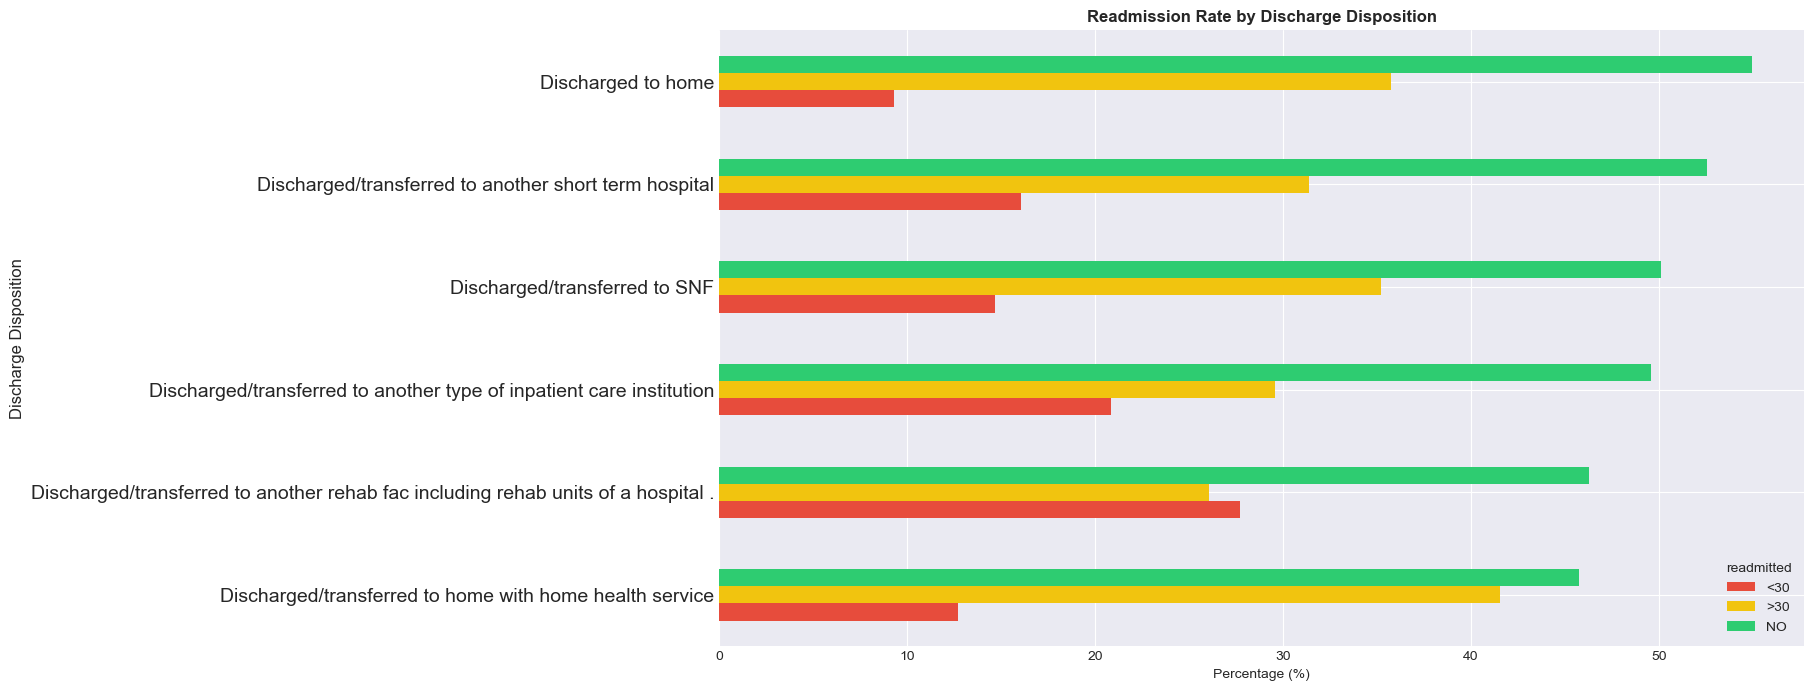

In [31]:
readmit_discharge = pd.crosstab(
    data_discharge_disposition_relevant.loc[
        data_discharge_disposition_relevant['discharge_disposition_id'].isin(discharge_list_final),
        'discharge_disposition_id'
    ],
    data_discharge_disposition_relevant['readmitted'],
    normalize='index'
) * 100

readmit_discharge_sorted = readmit_discharge.sort_values(by='NO', ascending=True)

# Plot
ax = readmit_discharge_sorted.plot(
    kind='barh',   # horizontal bars
    stacked=False,
    figsize=(14,8),
    color=colors
)
ax.set_title('Readmission Rate by Discharge Disposition', fontweight='bold', fontsize = 12)
ax.set_xlabel('Percentage (%)')
ax.set_ylabel('Discharge Disposition', fontsize = 12)
ax.tick_params(axis='y', labelsize=14)

#### Medicine Factors (Using Change vs Readmission) as well as (Ordinal vs Readmission)

In [32]:
len(medication_var)

23

In [33]:
data_med_encode = data.copy()

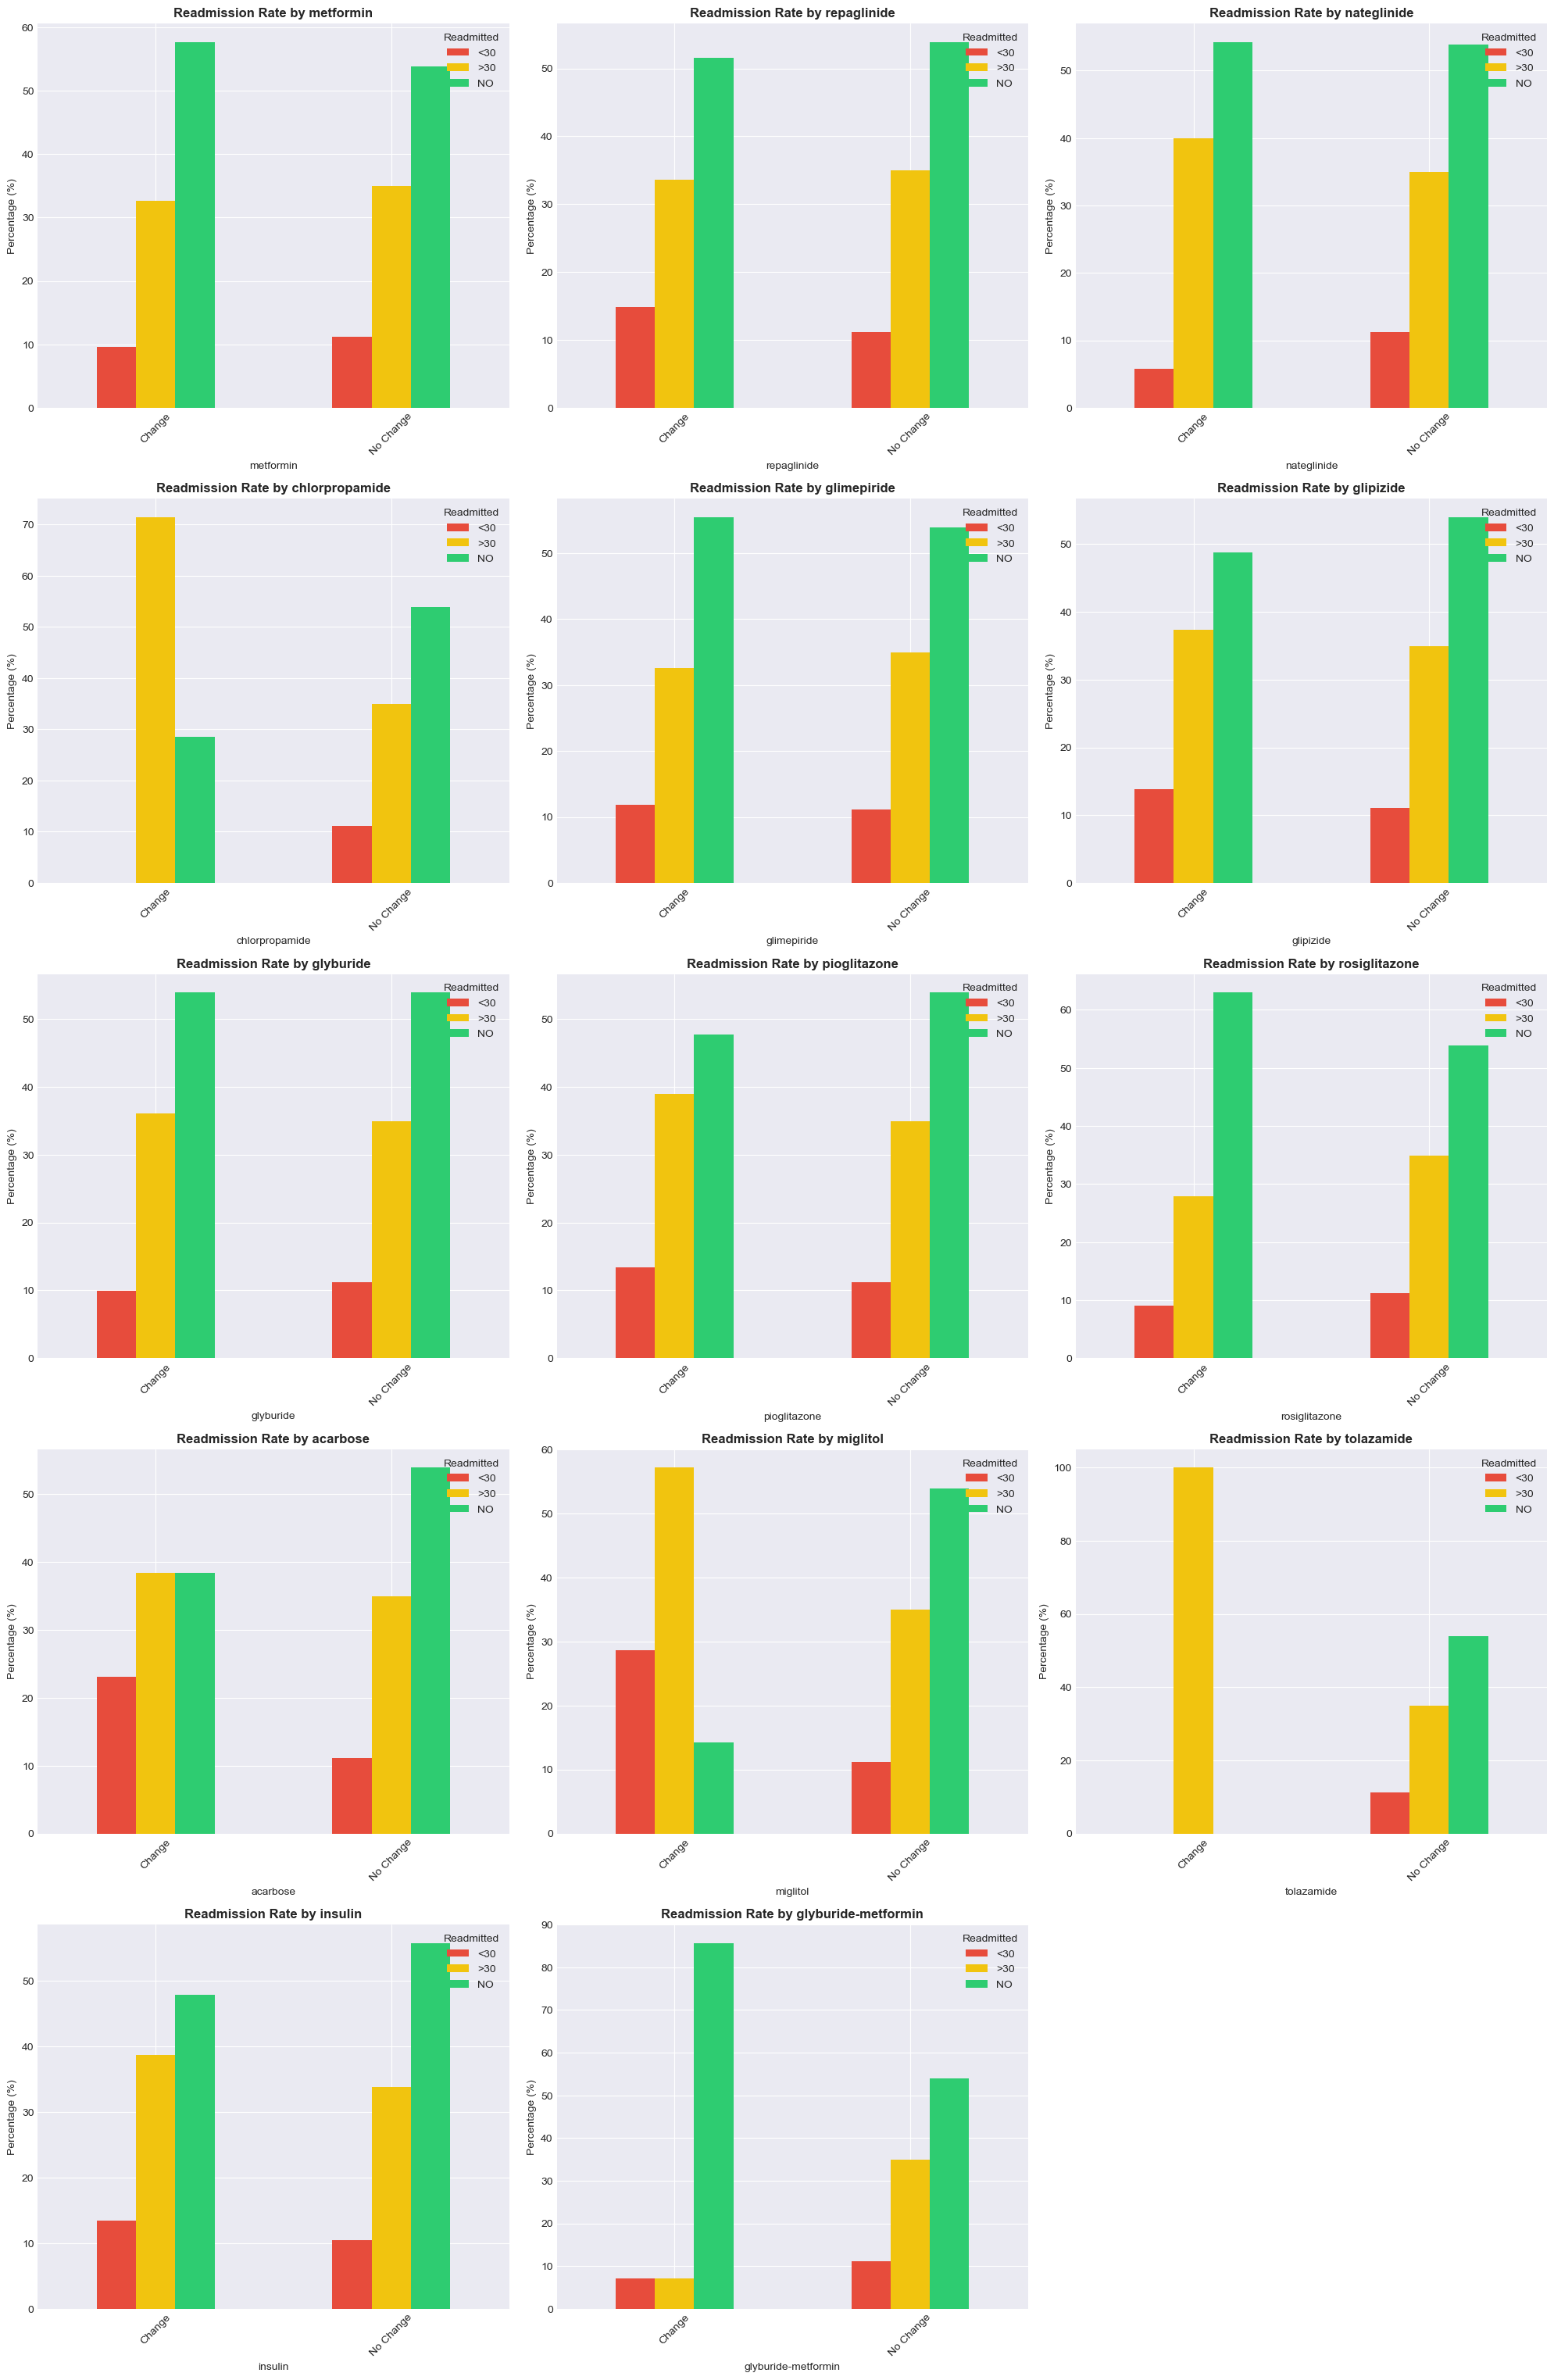

In [34]:
## up/down = change,  #otherwise = no change

data_med_encode[medication_var] = data[medication_var].replace({
    'Up':'Change',
    'Down': 'Change',
    'No':'No Change',
    'Steady': 'No Change'
})

medication_var_multiple_values = []

for col in medication_var:
    if data_med_encode[col].nunique() == 1:
        data_med_encode.drop(columns = {col}, axis = 1, inplace = True)
    else:
        medication_var_multiple_values.append(col)

# Create 8 rows × 3 columns of subplots (adjust if len(medication_var) is different)
fig, axes = plt.subplots(8, 3, figsize=(20, 48))
axes = axes.flatten()  # Convert 2D to 1D array for easier indexing

# Loop through each medication variable and its corresponding axis
for i, var in enumerate(medication_var_multiple_values):
    readmit_med_var = pd.crosstab(data_med_encode[var], data_med_encode['readmitted'], normalize='index') * 100
    readmit_med_var.plot(kind='bar', stacked=False, ax=axes[i], color = colors)
    axes[i].set_title(f'Readmission Rate by {var}', fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(title='Readmitted', loc = 'upper right')
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused axes if there are fewer vars than subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

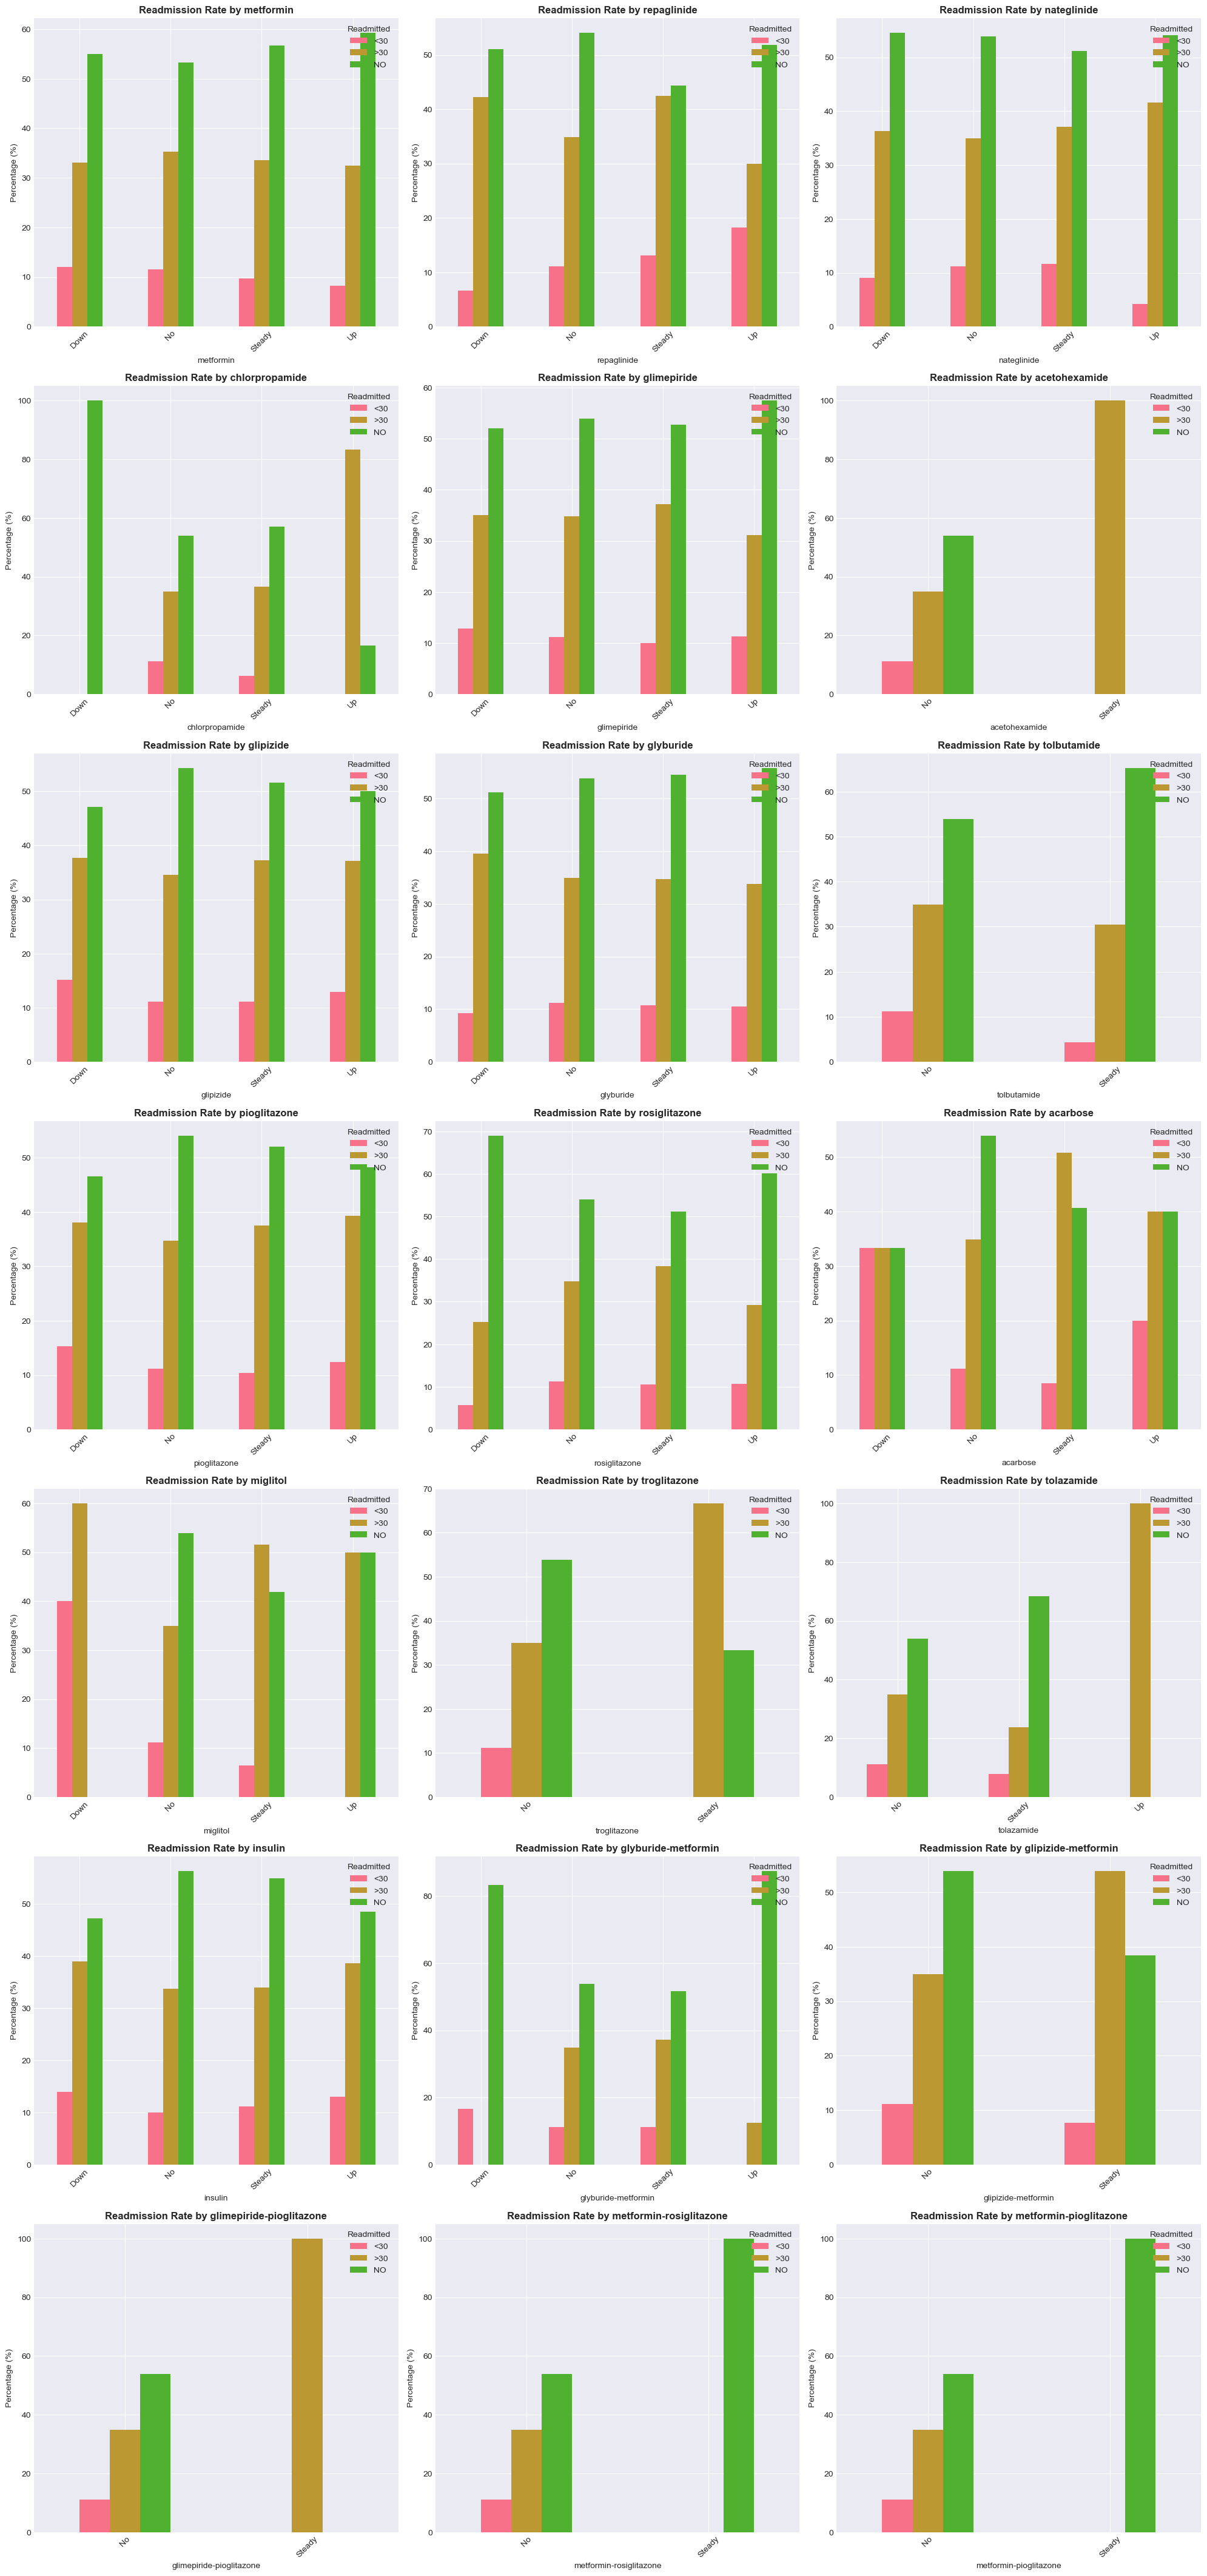

In [35]:
## ordinal

# Create 8 rows × 3 columns of subplots (adjust if len(medication_var) is different)
fig, axes = plt.subplots(8, 3, figsize=(20, 48))
axes = axes.flatten()  # Convert 2D to 1D array for easier indexing

data_meds = data.copy() 
medication_var_multiple_values2 = []

for col in medication_var:
    if data_meds[col].nunique() == 1:
        data_meds.drop(columns = {col}, axis = 1, inplace = True)
    else:
        medication_var_multiple_values2.append(col)

# Loop through each medication variable and its corresponding axis
for i, var in enumerate(medication_var_multiple_values2):
    readmit_med_var = pd.crosstab(data_meds[var], data_meds['readmitted'], normalize='index') * 100
    readmit_med_var.plot(kind='bar', stacked=False, ax=axes[i])
    axes[i].set_title(f'Readmission Rate by {var}', fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(title='Readmitted', loc = 'upper right')
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused axes if there are fewer vars than subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()